# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Understanding

## Import Dataset dan Sumber, Nama, Format, serta Tujuan Dataset

In [2]:
data = pd.read_excel("Amazon.xlsx") # Membaca file excel

In [3]:
amazon = pd.DataFrame(data) # Mengubahnya menjadi DataFrame
amazon

,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714
1,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694
2,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Art,Newell 322,7.280,4,1.9656
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152
4,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825
...,...,...,...,...,...,...,...,...,...,...
3198,CA-2013-125794,2013-09-30,2013-10-04,MarisLaWare@gmail.com,"United States,Los Angeles,California",Accessories,Memorex Mini Travel Drive 64 GB USB 2.0 Flash ...,36.240,1,15.2208
3199,CA-2014-121258,2014-02-27,2014-03-04,DaveBrooks@gmail.com,"United States,Costa Mesa,California",Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,15.6332
3200,CA-2014-121258,2014-02-27,2014-03-04,DaveBrooks@gmail.com,"United States,Costa Mesa,California",Phones,Aastra 57i VoIP phone,258.576,2,19.3932
3201,CA-2014-121258,2014-02-27,2014-03-04,DaveBrooks@gmail.com,"United States,Costa Mesa,California",Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,13.3200


In [4]:
amazon.info() # Untuk mengetahui jumlah baris dan kolom. Mengetahui missing value tiap kolom, nama nama kolom, dan tipe data tiap kolom

<class 'pandas.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      3203 non-null   str           
 1   Order Date    3203 non-null   datetime64[us]
 2   Ship Date     3203 non-null   datetime64[us]
 3   EmailID       3203 non-null   str           
 4   Geography     3203 non-null   str           
 5   Category      3203 non-null   str           
 6   Product Name  3203 non-null   str           
 7   Sales         3203 non-null   float64       
 8   Quantity      3203 non-null   int64         
 9   Profit        3203 non-null   float64       
dtypes: datetime64[us](2), float64(2), int64(1), str(5)
memory usage: 605.8 KB


In [5]:
amazon.describe() # Untuk mengetahui informasi statistik deskriptif pada kolom dengan tipe data integer dan float

,Order Date,Ship Date,Sales,Quantity,Profit
count,3203,3203,3203.000000,3203.000000,3203.000000
mean,2013-05-10 03:06:07.530440,2013-05-14 01:25:25.195129,226.493233,3.828910,33.849032
min,2011-01-07 00:00:00,2011-01-09 00:00:00,0.990000,1.000000,-3399.980000
25%,2012-05-22 00:00:00,2012-05-26 00:00:00,19.440000,2.000000,3.852000
50%,2013-07-22 00:00:00,2013-07-25 00:00:00,60.840000,3.000000,11.166400
75%,2014-05-23 00:00:00,2014-05-27 00:00:00,215.809000,5.000000,33.000400
max,2014-12-31 00:00:00,2015-01-06 00:00:00,13999.960000,14.000000,6719.980800
std,NaN,NaN,524.876877,2.260947,174.109081


## Data Exploration

### Membuat Copy Dataset

In [6]:
amazon_copy = amazon.copy() # Membuat copy dataset

### Cek Inkonsistensi Data

In [7]:
order_id_unique = pd.DataFrame(amazon_copy["Order ID"].unique())
order_id_unique.to_excel("order_id_unique.xlsx") # Ekstrak unique item untuk diperiksa inkonsistensi
order_id_unique.rename(columns={0 : "Order_ID"}, inplace=True)
order_id_unique # Memanggil unique item untuk diperiksa inkonsistensi

,Order_ID
0,CA-2013-138688
1,CA-2011-115812
2,CA-2013-161389
3,CA-2011-167164
4,CA-2011-143336
...,...
1606,CA-2014-137421
1607,US-2013-103674
1608,CA-2013-125794
1609,CA-2014-121258


In [8]:
email_id_unique = pd.DataFrame(amazon_copy["EmailID"].unique())
email_id_unique.to_excel("email_id_unique.xlsx") # Ekstrak unique item untuk diperiksa inkonsistensi
email_id_unique.rename(columns={0 : "Email_ID"}, inplace=True)
email_id_unique # Memanggil unique item untuk diperiksa inkonsistensi

,Email_ID
0,DarrinVanHuff@gmail.com
1,BrosinaHoffman@gmail.com
2,IreneMaddox@gmail.com
3,AlejandroGrove@gmail.com
4,ZuschussDonatelli@gmail.com
...,...
681,TroyBlackwell@gmail.com
682,DanLawera@gmail.com
683,SungChung@gmail.com
684,MaribethDona@gmail.com


In [9]:
geography_unique = pd.DataFrame(amazon_copy["Geography"].unique())
geography_unique.to_excel("geography_unique.xlsx") # Ekstrak unique item untuk diperiksa inkonsistensi
geography_unique.rename(columns={0 : "Geography"}, inplace=True)
geography_unique # Memanggil unique item untuk diperiksa inkonsistensi

,Geography
0,"United States,Los Angeles,California"
1,"United States,Seattle,Washington"
2,"United States,West Jordan,Utah"
3,"United States,San Francisco,California"
4,"United States,Orem,Utah"
...,...
165,"United States,Twin Falls,Idaho"
166,"United States,San Clemente,California"
167,"United States,Dublin,California"
168,"United States,San Luis Obispo,California"


In [10]:
category_unique = pd.DataFrame(amazon_copy["Category"].unique())
category_unique.to_excel("category_unique.xlsx") # Ekstrak unique item untuk diperiksa inkonsistensi
category_unique.rename(columns={0 : "Category"}, inplace=True)
category_unique # Memanggil unique item untuk diperiksa inkonsistensi

,Category
0,Labels
1,Furnishings
2,Art
3,Phones
4,Binders
5,Appliances
6,Tables
7,Storage
8,Accessories
9,Paper


In [11]:
product_name_unique = pd.DataFrame(amazon_copy["Product Name"].unique())
product_name_unique.to_excel("product_name_unique.xlsx") # Ekstrak unique item untuk diperiksa inkonsistensi
product_name_unique.rename(columns={0 : "Product_Name"}, inplace=True)
product_name_unique # Memanggil unique item untuk diperiksa inkonsistensi

,Product_Name
0,Self-Adhesive Address Labels for Typewriters b...
1,Eldon Expressions Wood and Plastic Desk Access...
2,Newell 322
3,Mitel 5320 IP Phone VoIP phone
4,DXL Angle-View Binders with Locking Rings by S...
...,...
1489,Eldon Econocleat Chair Mats for Low Pile Carpets
1490,Universal Recycled Hanging Pressboard Report B...
1491,Ibico Recycled Grain-Textured Covers
1492,"Bush Andora Conference Table, Maple/Graphite G..."


### Jumlah dan Persentase Missing Value

In [12]:
amazonnull = amazon_copy.isnull().sum() # Mencari jumlah missing value
amazonnullpercentage = amazonnull / len(amazon_copy) * 100 # Mencari persentase missing value

In [13]:
print(f"Jumlah missing value : \n{amazonnull}")
print(f"Persentase missing value : \n{amazonnullpercentage}")

Jumlah missing value : 
Order ID        0
Order Date      0
Ship Date       0
EmailID         0
Geography       0
Category        0
Product Name    0
Sales           0
Quantity        0
Profit          0
dtype: int64
Persentase missing value : 
Order ID        0.0
Order Date      0.0
Ship Date       0.0
EmailID         0.0
Geography       0.0
Category        0.0
Product Name    0.0
Sales           0.0
Quantity        0.0
Profit          0.0
dtype: float64


### Jumlah dan Persentase Duplicate Value

In [14]:
duplicate_all = amazon_copy.duplicated().sum() # Memeriksa jumlah duplicate value berdasarkan tiap baris
persent_duplicate_all = duplicate_all /len(amazon_copy)*100 # Menghitung persentase duplicate value
print(f"Jumlah Baris yang duplikat = {duplicate_all}")
print(f"Persentase Baris yang duplikat = {persent_duplicate_all:.2f}%")

Jumlah Baris yang duplikat = 0
Persentase Baris yang duplikat = 0.00%


### Encoder Kolom Kategori Untuk Periksa Outlier

In [15]:
from sklearn.preprocessing import LabelEncoder # Memanggil Library untuk LabelEncoder

In [16]:
le = LabelEncoder()

In [17]:
'''Membuat LabelEncoder pada tiap Kolom dengan tipe data string'''
amazon_copy["Order_ID_Code"] = le.fit_transform(amazon_copy["Order ID"])
amazon_copy["EmailID_Code"] = le.fit_transform(amazon_copy["EmailID"])
amazon_copy["Geography_Code"] = le.fit_transform(amazon_copy["Geography"])
amazon_copy["Category_Code"] = le.fit_transform(amazon_copy["Category"])
amazon_copy["Product_Name_Code"] = le.fit_transform(amazon_copy["Product Name"])

### Pemeriksaan Outlier Dengan Boxplot

In [18]:
'''Membuat Variabel Baru Dari Dataset Copy Berupa Kolom Dengan Tipe Data Numerik'''
explore_numerik = amazon_copy[["Order_ID_Code", "EmailID_Code", "Geography_Code", "Category_Code", "Product_Name_Code", "Sales", "Quantity", "Profit"]]

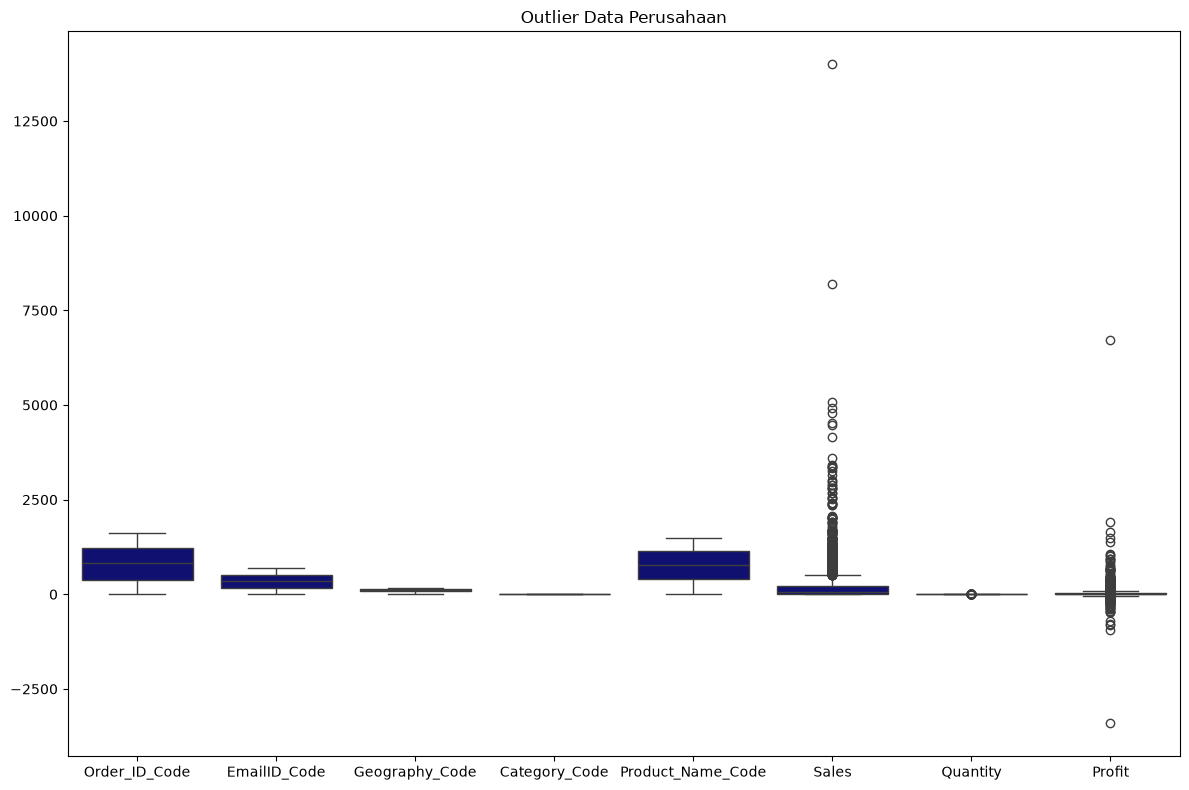

In [19]:
plt.figure(figsize=(12,8))
sns.boxplot(explore_numerik, color="navy")
plt.title("Outlier Data Perusahaan")
plt.tight_layout()
plt.show()

### Jumlah dan Persentase Outlier Dengan IQR

In [20]:
'''Membuat Variabel Baru Untuk Mengambil Nama Kolom Dengan Tipe Data Numerikal'''
kolom_outlier = amazon_copy.select_dtypes(include=["int64", "float64"]).columns

In [21]:
kolom_outlier

Index(['Sales', 'Quantity', 'Profit', 'Order_ID_Code', 'EmailID_Code',
       'Geography_Code', 'Category_Code', 'Product_Name_Code'],
      dtype='str')

In [22]:
for i in kolom_outlier :
    Q1 = amazon_copy[i].quantile(0.25)
    Q3 = amazon_copy[i].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier = (amazon_copy[i] < lower) | (amazon_copy[i] > upper)
    jumlah_outlier = outlier.sum() # Mengetahui jumlah outlier pada kolom
    persentase_outlier = jumlah_outlier/len(outlier) * 100 # Mengetahui persentase outlier pada kolom
    print(f"Jumlah Outlier pada Kolom {i} : {jumlah_outlier}")
    print(f"Persentase Outlier pada Kolom {i} : {persentase_outlier:.2f}%\n")

Jumlah Outlier pada Kolom Sales : 368
Persentase Outlier pada Kolom Sales : 11.49%

Jumlah Outlier pada Kolom Quantity : 62
Persentase Outlier pada Kolom Quantity : 1.94%

Jumlah Outlier pada Kolom Profit : 465
Persentase Outlier pada Kolom Profit : 14.52%

Jumlah Outlier pada Kolom Order_ID_Code : 0
Persentase Outlier pada Kolom Order_ID_Code : 0.00%

Jumlah Outlier pada Kolom EmailID_Code : 0
Persentase Outlier pada Kolom EmailID_Code : 0.00%

Jumlah Outlier pada Kolom Geography_Code : 0
Persentase Outlier pada Kolom Geography_Code : 0.00%

Jumlah Outlier pada Kolom Category_Code : 0
Persentase Outlier pada Kolom Category_Code : 0.00%

Jumlah Outlier pada Kolom Product_Name_Code : 0
Persentase Outlier pada Kolom Product_Name_Code : 0.00%



### Cek Distribusi Data Dengan Histogram

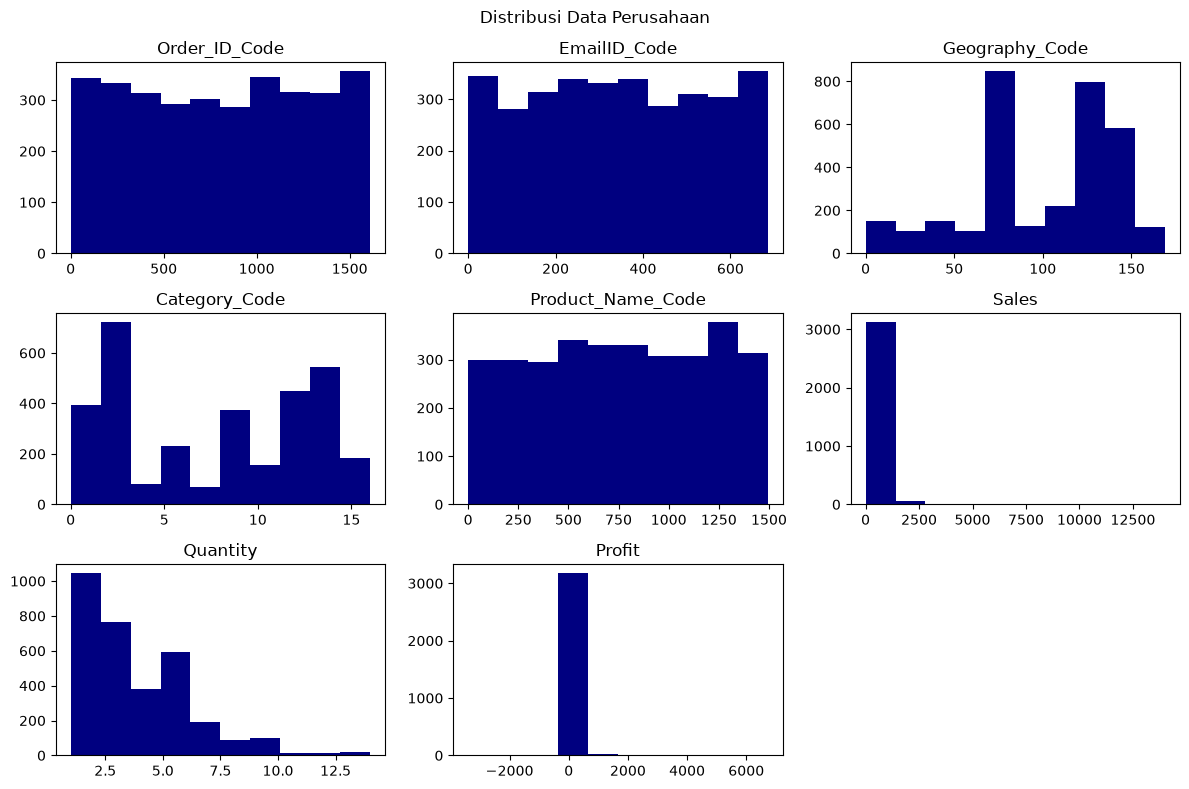

In [23]:
explore_numerik.hist(color='navy', figsize=(12,8), grid=False)
plt.suptitle("Distribusi Data Perusahaan")
plt.tight_layout()
plt.show()

### Cek Distribusi Data Dengan KDE Plot

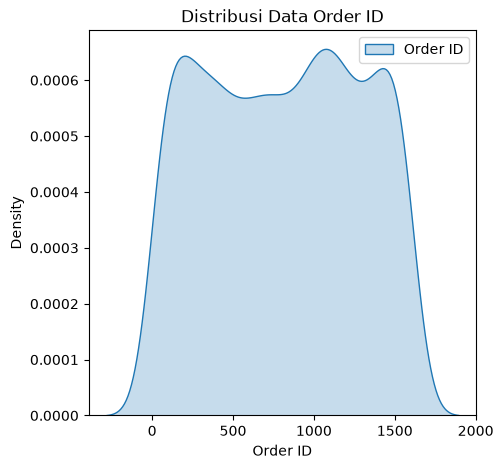

In [24]:
'''Distribusi Order ID'''
plt.figure(figsize=(5,5))
sns.kdeplot(explore_numerik["Order_ID_Code"], fill=True, label="Order ID")
plt.title("Distribusi Data Order ID")
plt.xlabel("Order ID")
plt.legend()
plt.show()

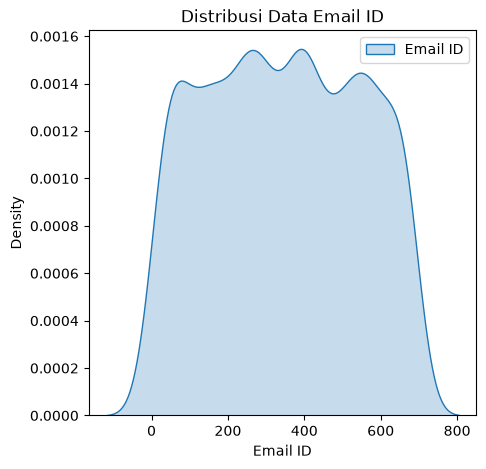

In [25]:
'''Distribusi Email ID'''
plt.figure(figsize=(5,5))
sns.kdeplot(explore_numerik["EmailID_Code"], fill=True, label="Email ID")
plt.title("Distribusi Data Email ID")
plt.xlabel("Email ID")
plt.legend()
plt.show()

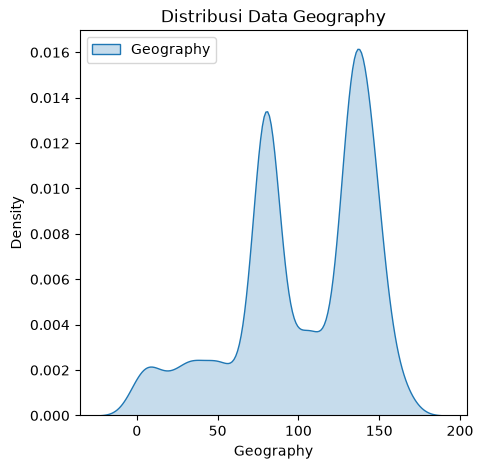

In [26]:
'''Distribusi Geography'''
plt.figure(figsize=(5,5))
sns.kdeplot(explore_numerik["Geography_Code"], fill=True, label="Geography")
plt.title("Distribusi Data Geography")
plt.xlabel("Geography")
plt.legend()
plt.show()

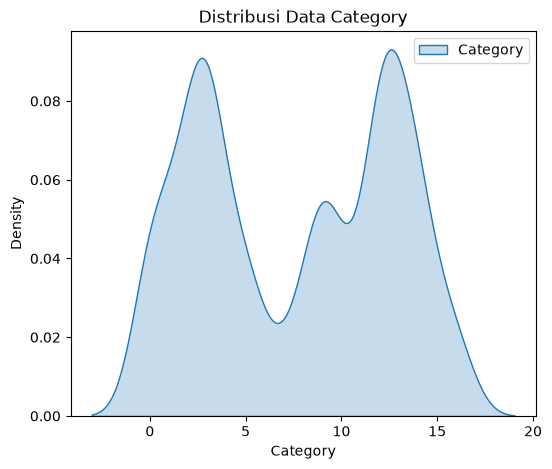

In [27]:
'''Distribusi Category'''
plt.figure(figsize=(6,5))
sns.kdeplot(explore_numerik["Category_Code"], fill=True, label="Category")
plt.title("Distribusi Data Category")
plt.xlabel("Category")
plt.legend()
plt.show()

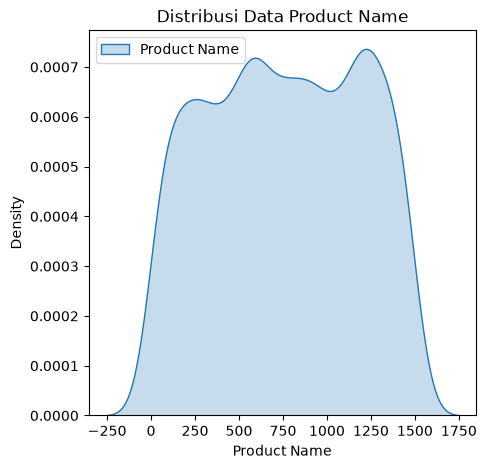

In [28]:
'''Distribusi Product Name'''
plt.figure(figsize=(5,5))
sns.kdeplot(explore_numerik["Product_Name_Code"], fill=True, label="Product Name")
plt.title("Distribusi Data Product Name")
plt.xlabel("Product Name")
plt.legend()
plt.show()

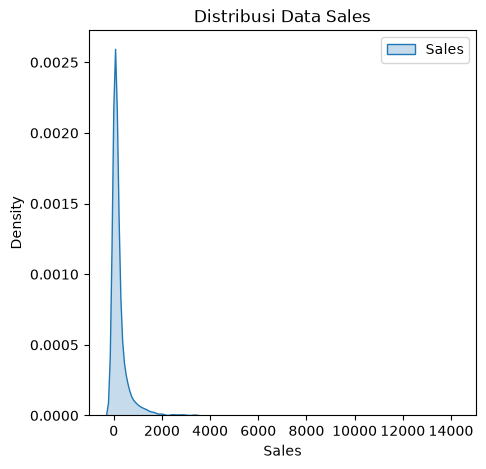

In [29]:
'''Distribusi Sales'''
plt.figure(figsize=(5,5))
sns.kdeplot(explore_numerik["Sales"], fill=True, label="Sales")
plt.title("Distribusi Data Sales")
plt.xlabel("Sales")
plt.legend()
plt.show()

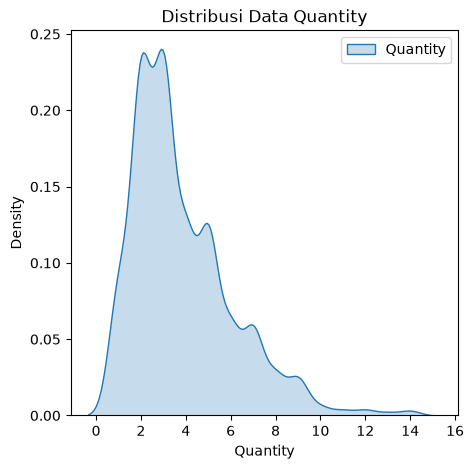

In [30]:
'''Distribusi Quantity'''
plt.figure(figsize=(5,5))
sns.kdeplot(explore_numerik["Quantity"], fill=True, label="Quantity")
plt.title("Distribusi Data Quantity")
plt.xlabel("Quantity")
plt.legend()
plt.show()

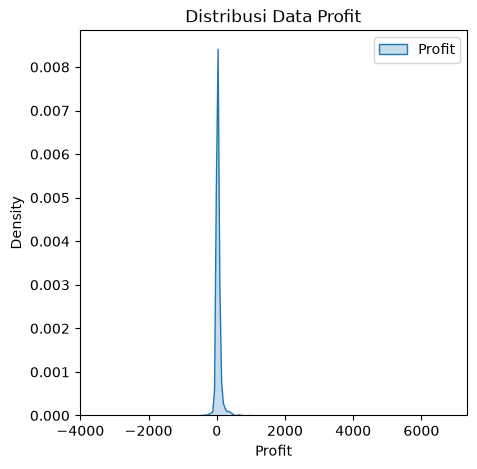

In [31]:
'''Distribusi Profit'''
plt.figure(figsize=(5,5))
sns.kdeplot(explore_numerik["Profit"], fill=True, label="Profit")
plt.title("Distribusi Data Profit")
plt.xlabel("Profit")
plt.legend()
plt.show()

### Cek Distribusi Data Dengan Uji Shapiro-Wilk

In [32]:
from scipy.stats import shapiro

In [33]:
for x in explore_numerik : 
    stat, p = shapiro(amazon_copy[x])
    print(f"p value Kolom {x} : {p:.3f}")
    if p >= 0.05 :
        print(f"Kolom {x} terdistribusi normal")
    else :
        print(f"Kolom {x} tidak terdistribusi normal\n")

p value Kolom Order_ID_Code : 0.000
Kolom Order_ID_Code tidak terdistribusi normal

p value Kolom EmailID_Code : 0.000
Kolom EmailID_Code tidak terdistribusi normal

p value Kolom Geography_Code : 0.000
Kolom Geography_Code tidak terdistribusi normal

p value Kolom Category_Code : 0.000
Kolom Category_Code tidak terdistribusi normal

p value Kolom Product_Name_Code : 0.000
Kolom Product_Name_Code tidak terdistribusi normal

p value Kolom Sales : 0.000
Kolom Sales tidak terdistribusi normal

p value Kolom Quantity : 0.000
Kolom Quantity tidak terdistribusi normal

p value Kolom Profit : 0.000
Kolom Profit tidak terdistribusi normal



### Insight Berdasarkan Hasil Eksplorasi

# Data Preparation

## Data Cleaning

### Cleaning Outlier

In [34]:
'''Penanganan Outlier Kolom Sales dengan Transformasi Capping'''
Q1_sales = amazon_copy["Sales"].quantile(0.25)
Q3_sales = amazon_copy["Sales"].quantile(0.75)
IQR_sales = Q3_sales - Q1_sales
lower_sales = Q1_sales - 1.5 * IQR_sales
upper_sales = Q3_sales + 1.5 * IQR_sales

amazon_copy["Sales_Cap"] = amazon_copy["Sales"].clip(lower_sales, upper_sales) # Transformasi Capping kolom Sales ke kolom Sales_Cap
Q1_sales_cap = amazon_copy["Sales_Cap"].quantile(0.25)
Q3_sales_cap = amazon_copy["Sales_Cap"].quantile(0.75)
IQR_sales_cap = Q3_sales_cap - Q1_sales_cap
lower_sales_cap = Q1_sales_cap - 1.5 * IQR_sales_cap
upper_sales_cap = Q3_sales_cap + 1.5 * IQR_sales_cap
outlier_sales_cap = (amazon_copy["Sales_Cap"] < lower_sales_cap) | (amazon_copy["Sales_Cap"] > upper_sales_cap)
jumlah_outlier_sales_cap = outlier_sales_cap.sum() # Mengetahui jumlah outlier pada kolom Sales_Cap
persentase_outlier_sales_cap = jumlah_outlier_sales_cap/len(amazon_copy) * 100 # Mengetahui persentase outlier pada kolom Sales_Cap
print(f"Jumlah Outlier pada Kolom Sales_Cap : {jumlah_outlier_sales_cap}")
print(f"Persentase Outlier pada Kolom Sales_Cap : {persentase_outlier_sales_cap}")

Jumlah Outlier pada Kolom Sales_Cap : 0
Persentase Outlier pada Kolom Sales_Cap : 0.0


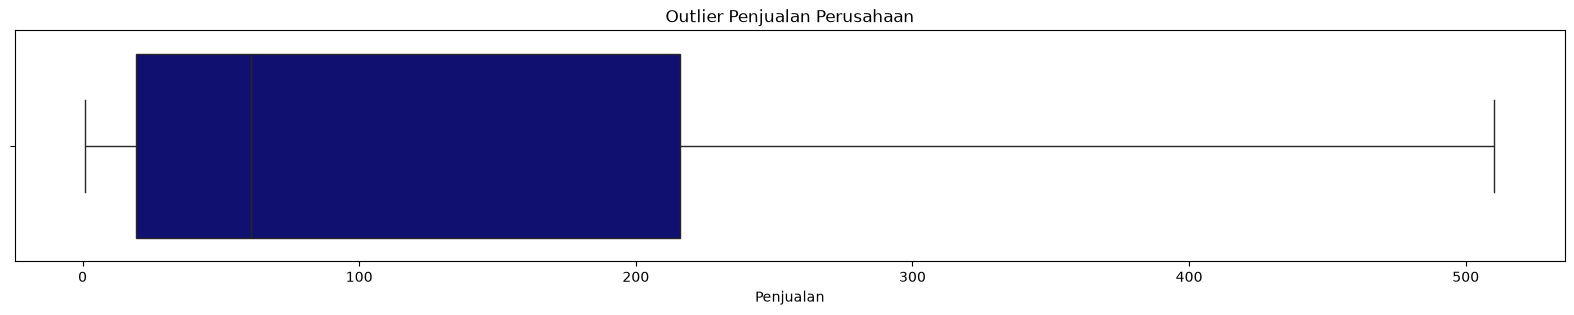

In [35]:
'''Pemeriksaan Outlier dengan Boxplot setelah Transformasi Capping'''
plt.figure(figsize=(20,3))
sns.boxplot(x=amazon_copy["Sales_Cap"], color="navy")
plt.title("Outlier Penjualan Perusahaan")
plt.xlabel("Penjualan")
plt.show()

In [36]:
'''Penanganan Outlier Kolom Quantity dengan Transformasi Log'''
amazon_copy["Quantity_Log"] = np.log(amazon_copy["Quantity"]) # Transformasi Log kolom Quantity ke kolom Quantity_Log
Q1_quantity_log = amazon_copy["Quantity_Log"].quantile(0.25)
Q3_quantity_log = amazon_copy["Quantity_Log"].quantile(0.75)
IQR_quantity_log = Q3_quantity_log - Q1_quantity_log
lower_quantity_log = Q1_quantity_log - 1.5 * IQR_quantity_log
upper_quantity_log = Q3_quantity_log + 1.5 * IQR_quantity_log
outlier_quantity_log = (amazon_copy["Quantity_Log"] < lower_quantity_log) | (amazon_copy["Quantity_Log"] > upper_quantity_log)
jumlah_outlier_quantity_log = outlier_quantity_log.sum() # Mengetahui jumlah outlier pada kolom Quantity_Log
persentase_outlier_quantity_log = jumlah_outlier_quantity_log/len(amazon_copy) * 100 # Mengetahui persentase outlier pada kolom Quantity_Log
print(f"Jumlah Outlier pada Kolom Quantity_Log : {jumlah_outlier_quantity_log}")
print(f"Persentase Outlier pada Kolom Quantity_Log : {persentase_outlier_quantity_log}")

Jumlah Outlier pada Kolom Quantity_Log : 0
Persentase Outlier pada Kolom Quantity_Log : 0.0


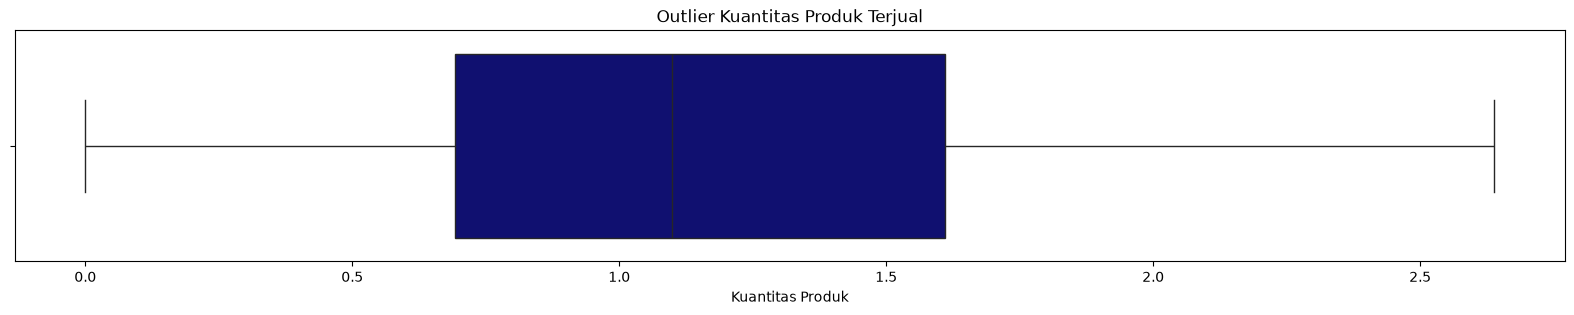

In [37]:
'''Pemeriksaan Outlier dengan Boxplot setelah Transformasi Log'''
plt.figure(figsize=(20,3))
sns.boxplot(x=amazon_copy["Quantity_Log"], color="navy")
plt.title("Outlier Kuantitas Produk Terjual")
plt.xlabel("Kuantitas Produk")
plt.show()

In [38]:
'''Penanganan Outlier Kolom Profit dengan Transformasi Capping'''
Q1_profit = amazon_copy["Profit"].quantile(0.25)
Q3_profit = amazon_copy["Profit"].quantile(0.75)
IQR_profit = Q3_profit - Q1_profit
lower_profit = Q1_profit - 1.5 * IQR_profit
upper_profit = Q3_profit + 1.5 * IQR_profit

amazon_copy["Profit_Cap"] = amazon_copy["Profit"].clip(lower_profit, upper_profit) # Transformasi Capping kolom Profit ke kolom Profit_Cap
Q1_profit_cap = amazon_copy["Profit_Cap"].quantile(0.25)
Q3_profit_cap = amazon_copy["Profit_Cap"].quantile(0.75)
IQR_profit_cap = Q3_profit_cap - Q1_profit_cap
lower_profit_cap = Q1_profit_cap - 1.5 * IQR_profit_cap
upper_profit_cap = Q3_profit_cap + 1.5 * IQR_profit_cap
outlier_profit_cap = (amazon_copy["Profit_Cap"] < lower_profit_cap) | (amazon_copy["Profit_Cap"] > upper_profit_cap)
jumlah_outlier_profit_cap = outlier_profit_cap.sum() # Mengetahui jumlah outlier pada kolom Profit_Cap
persentase_outlier_profit_cap = jumlah_outlier_profit_cap/len(amazon_copy) * 100 # Mengetahui persentase outlier pada kolom Profit_Cap
print(f"Jumlah Outlier pada Kolom Profit_Cap : {jumlah_outlier_profit_cap}")
print(f"Persentase Outlier pada Kolom Profit_Cap : {persentase_outlier_profit_cap}")

Jumlah Outlier pada Kolom Profit_Cap : 0
Persentase Outlier pada Kolom Profit_Cap : 0.0


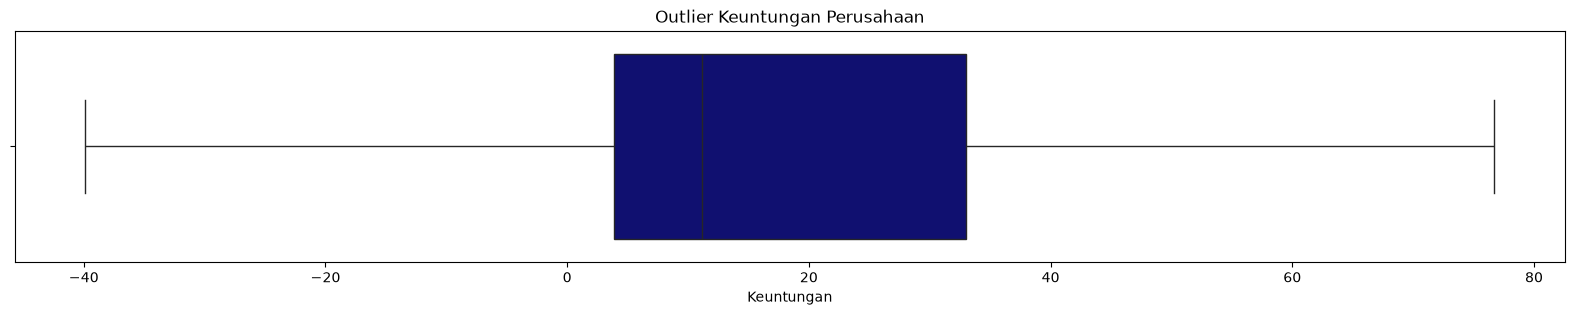

In [39]:
'''Pemeriksaan Outlier dengan Boxplot setelah Transformasi Capping'''
plt.figure(figsize=(20,3))
sns.boxplot(x=amazon_copy["Profit_Cap"], color="navy")
plt.title("Outlier Keuntungan Perusahaan")
plt.xlabel("Keuntungan")
plt.show()

### Cek Kembali Tipe Data

In [40]:
amazon_copy.info() # Dapat digunakkan untuk cek tipe data

<class 'pandas.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           3203 non-null   str           
 1   Order Date         3203 non-null   datetime64[us]
 2   Ship Date          3203 non-null   datetime64[us]
 3   EmailID            3203 non-null   str           
 4   Geography          3203 non-null   str           
 5   Category           3203 non-null   str           
 6   Product Name       3203 non-null   str           
 7   Sales              3203 non-null   float64       
 8   Quantity           3203 non-null   int64         
 9   Profit             3203 non-null   float64       
 10  Order_ID_Code      3203 non-null   int64         
 11  EmailID_Code       3203 non-null   int64         
 12  Geography_Code     3203 non-null   int64         
 13  Category_Code      3203 non-null   int64         
 14  Product_Name_Code  

## Feature Engineering

In [41]:
'''Membuat Kolom Baru Berdasarkan Perhitungan'''
amazon_copy["Modal"] = amazon_copy["Sales"] - amazon_copy["Profit"]    # Membuat Kolom Modal yang dihasilkan dari Sales dikurangi Profit

# EDA (Analisa Data)

## Analisa Trend Keuntungan Perusahaan Menggunakan Line Chart

In [42]:
'''Membuat tabel baru berupa jumlah profit di setiap tahun'''
amazon_copy["Tahun"] = amazon_copy["Order Date"].dt.year # Mengambil Tahun dari Kolom Order Date
profit_tahunan = amazon_copy.groupby("Tahun").agg(
    Total_Profit = ("Profit", "sum")
).reset_index()                                          # Mengambil Unique item dari Tahun dan menjumlahkan keuntungan tiap tahun
profit_tahunan

,Tahun,Total_Profit
0,2011,20065.6912
1,2012,20492.1947
2,2013,23959.9374
3,2014,43900.6256


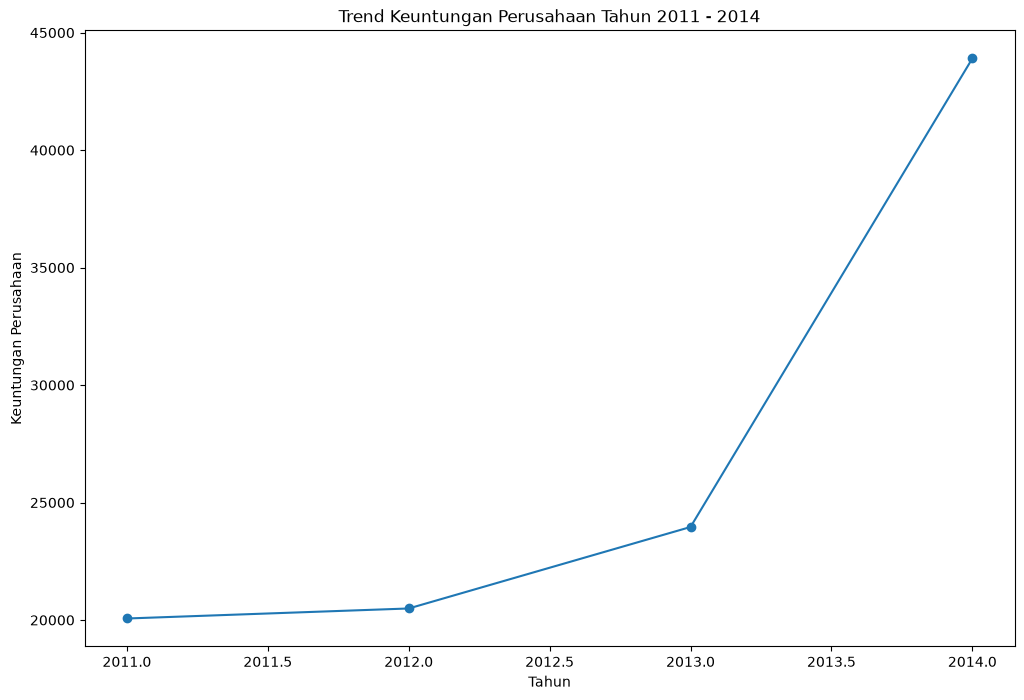

In [43]:
plt.figure(figsize=(12,8))
plt.plot(profit_tahunan["Tahun"], profit_tahunan["Total_Profit"], marker="o")
plt.title("Trend Keuntungan Perusahaan Tahun 2011 - 2014")
plt.xlabel("Tahun")
plt.ylabel("Keuntungan Perusahaan")
plt.show()

## Hubungan Penjualan (Sales) dengan Keuntungan (Profit) Menggunakan Scatterplot

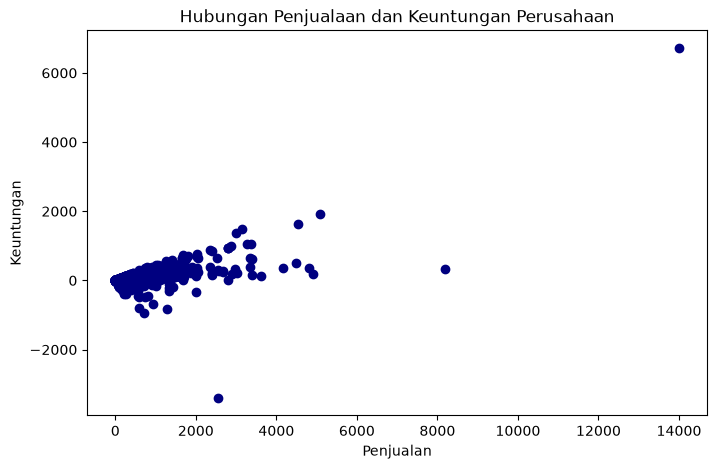

In [44]:
plt.figure(figsize=(8,5))
plt.scatter(
    amazon_copy["Sales"],
    amazon_copy["Profit"],
    color="navy"
)
plt.title("Hubungan Penjualaan dan Keuntungan Perusahaan")
plt.xlabel("Penjualan")
plt.ylabel("Keuntungan")
plt.show()

## Analisis Bivariat Menggunakan Heatmap

In [45]:
'''Membuat Variabel Baru Dari Dataset Copy Yang Sudah Diperbarui Berupa Kolom Dengan Tipe Data Numerik'''
statistik = amazon_copy[["Order_ID_Code", "EmailID_Code", "Geography_Code", "Category_Code", "Product_Name_Code", "Sales", "Quantity", "Profit", "Modal"]]

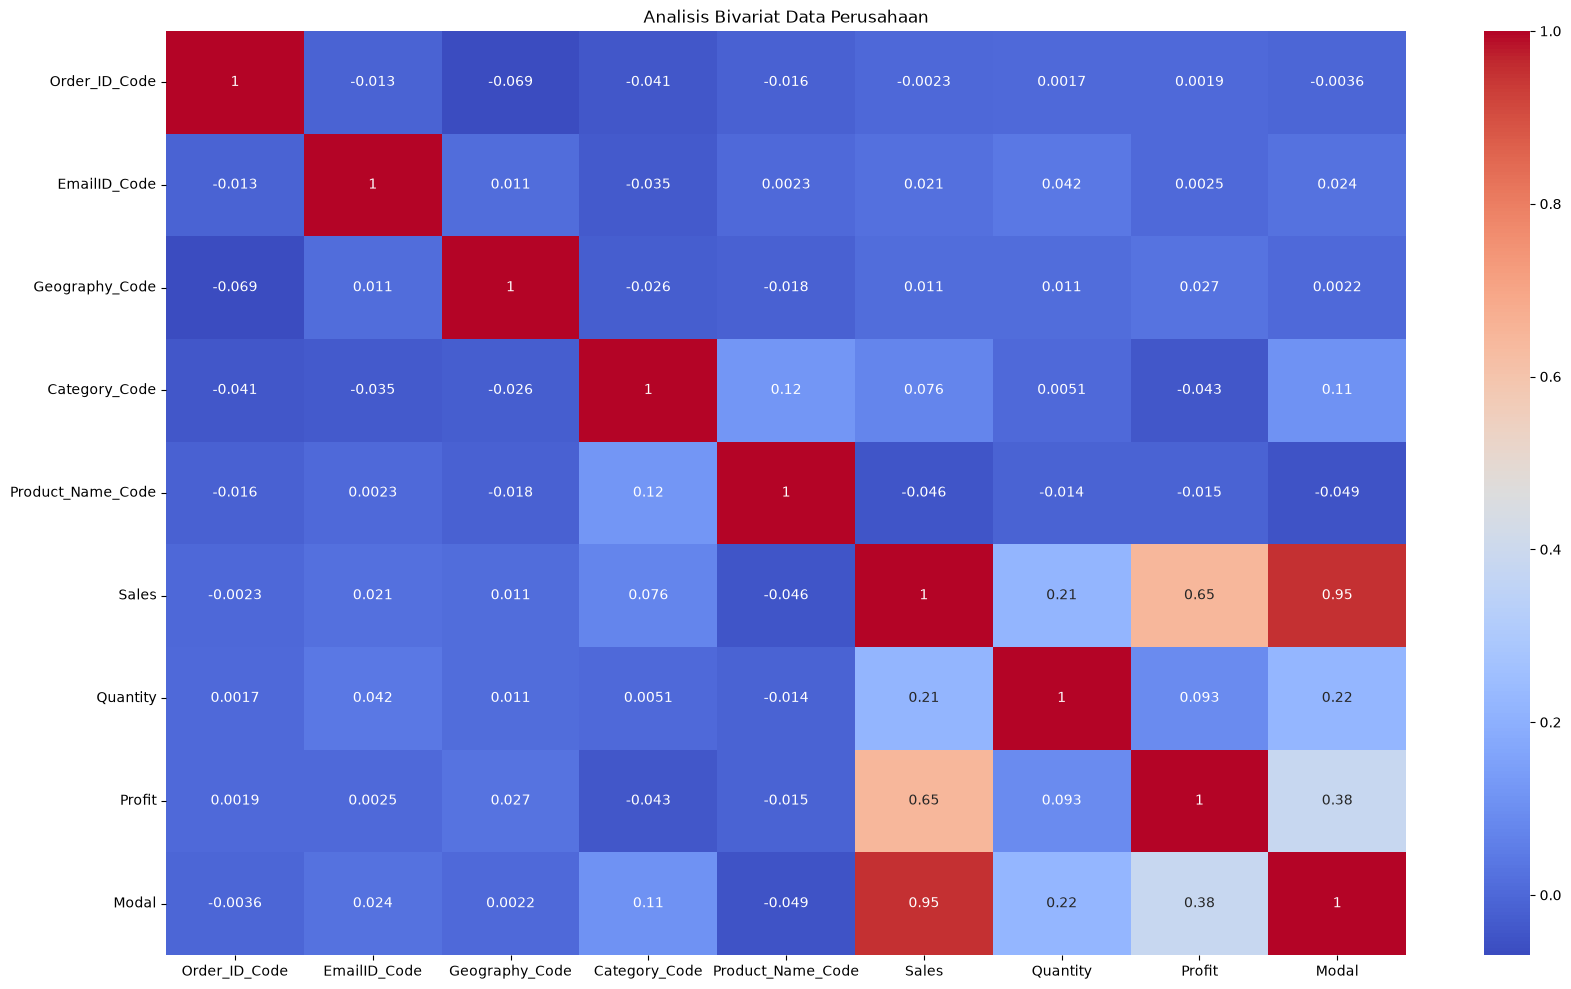

In [46]:
amazon_corr = statistik.corr()
plt.figure(figsize=(20, 12))
sns.heatmap(
    amazon_corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Analisis Bivariat Data Perusahaan")
plt.show()

## Analsis Multivariat Menggunakan Pairplot

<Figure size 800x500 with 0 Axes>

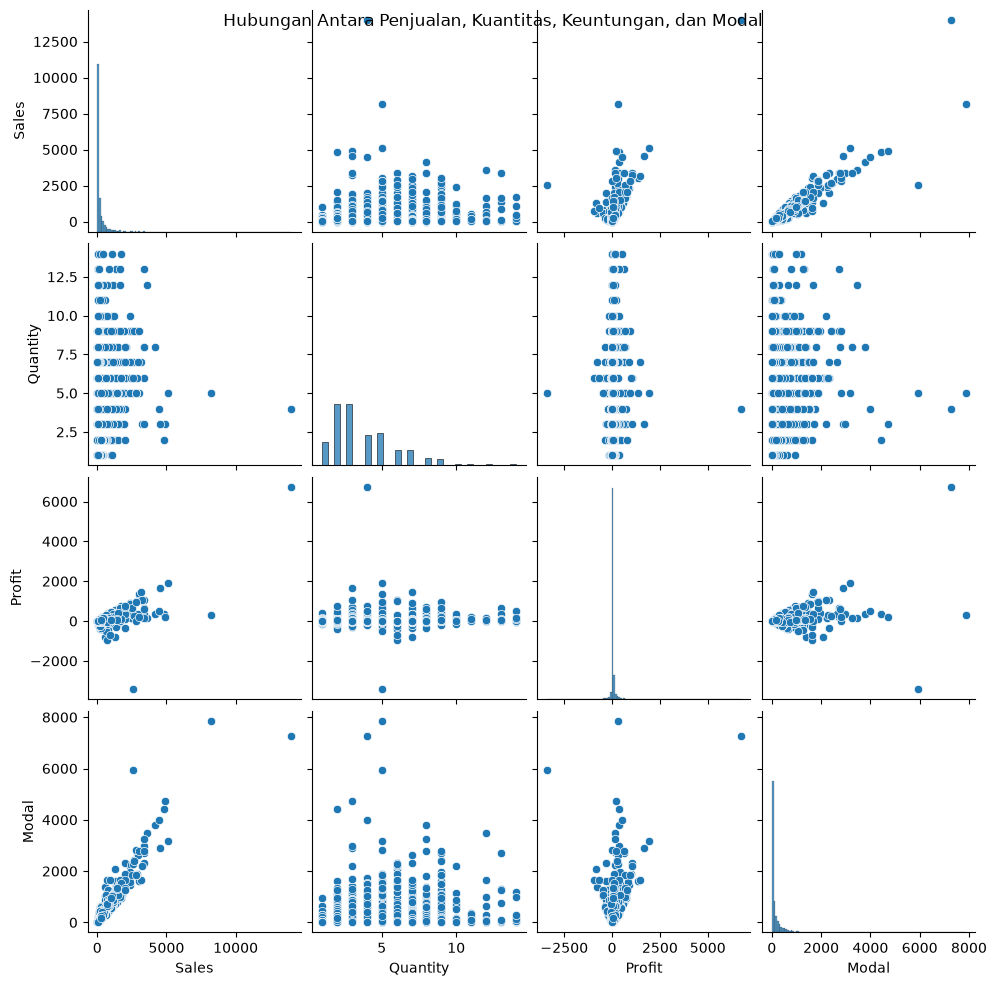

In [47]:
plt.figure(figsize=(8,5))
sns.pairplot(statistik[["Sales", "Quantity", "Profit", "Modal"]])
plt.suptitle("Hubungan Antara Penjualan, Kuantitas, Keuntungan, dan Modal")
plt.show()

## Kategori Barang Yang Memberikan Keuntungan Terbesar Menggunakan Grouping dan Aggregation

In [48]:
'''Kategori dengan profit tertinggi ke terendah'''
kategori = amazon_copy.groupby("Category").agg(
    Total_Keuntungan = ("Profit", "sum")
).sort_values(by="Total_Keuntungan", ascending=False).reset_index()
kategori

,Category,Total_Keuntungan
0,Copiers,19327.2351
1,Accessories,16484.5983
2,Binders,16096.8016
3,Paper,12119.2364
4,Phones,9110.7426
5,Storage,8645.3222
6,Appliances,8261.2699
7,Furnishings,7641.2704
8,Chairs,4027.5843
9,Art,2374.0970


## Kategori Barang Yang Memberikan Keuntungan Terbesar Menggunakan Bar Chart

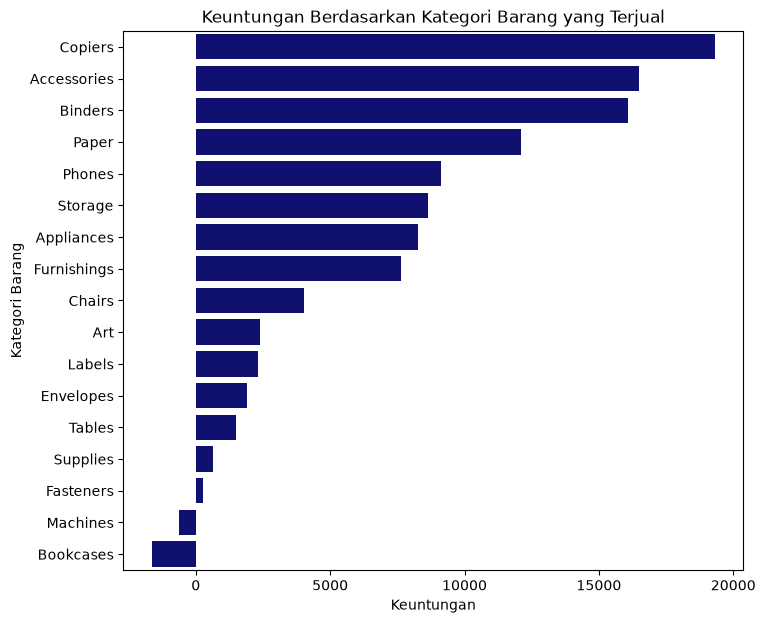

In [49]:
plt.figure(figsize=(8,7))
sns.barplot(
    x=kategori["Total_Keuntungan"],
    y=kategori["Category"],
    errorbar = ("ci", False),
    color="navy"
)
plt.title("Keuntungan Berdasarkan Kategori Barang yang Terjual")
plt.xlabel("Keuntungan")
plt.ylabel("Kategori Barang")
plt.show()

## Analisis Lokasi Geography dengan Keuntungan Terbesar Dalam Penjualan Copiers dengan Crosstab

In [50]:
'''Geography yang memiliki penjualan Copiers dengan profit tertinggi ke terendah'''
pd.crosstab(
    amazon_copy["Geography"],
    amazon_copy["Category"],
    values=amazon_copy["Profit"],
    aggfunc="sum"
).sort_values("Copiers", ascending=False)

Category,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
Geography,,,,,,,,,,,,,,,,,
"United States,Seattle,Washington",3715.1850,329.1988,194.0753,5904.3276,570.0054,521.2414,8290.4449,137.2849,42.3756,813.7234,165.7729,448.2445,1445.4253,577.9738,1659.3006,37.6693,4303.8480
"United States,Los Angeles,California",5667.2927,2593.1313,532.8627,3411.7499,499.7230,572.9043,3704.9333,533.2527,85.3274,2027.1744,287.6783,1954.1657,3022.0118,2582.1462,2892.6561,101.9585,-28.2104
"United States,San Francisco,California",2046.6957,1765.7936,365.4094,2258.5381,669.9770,445.5746,2132.9649,354.8139,33.0910,1031.0404,365.2094,977.2715,2355.7534,1237.8229,1526.2752,596.3654,-655.2110
"United States,Great Falls,Montana",91.3248,NaN,NaN,2.2098,NaN,NaN,1379.9770,NaN,NaN,NaN,NaN,NaN,5.3820,9.2386,94.5749,NaN,NaN
"United States,Des Moines,Washington",NaN,NaN,NaN,33.6400,NaN,-2.6997,1151.9793,30.9918,NaN,NaN,NaN,NaN,8.7138,27.7182,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"United States,Westminster,California",27.5422,485.4160,20.8568,17.3018,NaN,25.8980,NaN,NaN,2.3312,73.2420,NaN,NaN,11.5432,99.5574,NaN,NaN,NaN
"United States,Whittier,California",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.4768,NaN,NaN,NaN
"United States,Woodland,California",NaN,NaN,NaN,7.5864,NaN,NaN,NaN,NaN,NaN,NaN,1.8000,NaN,NaN,23.9984,NaN,NaN,NaN


## Filtering Kategori Barang Yang Menyebabkan Kerugian

In [51]:
kerugian = kategori[kategori["Total_Keuntungan"]<0]

In [52]:
kerugian

,Category,Total_Keuntungan
15,Machines,-618.9264
16,Bookcases,-1646.5117


## Randomisasi

In [53]:
amazon_random = amazon_copy.sample(frac=0.5, random_state=31)

In [54]:
kategori_random = amazon_random.groupby("Category").agg(
    Total_Keuntungan = ("Profit", "sum")
).sort_values(by="Total_Keuntungan", ascending=False).reset_index()
kategori_random

,Category,Total_Keuntungan
0,Copiers,13009.3444
1,Accessories,8371.1539
2,Binders,8129.6039
3,Paper,5713.1155
4,Phones,5074.2024
5,Storage,4569.8726
6,Appliances,3615.2422
7,Furnishings,3383.5517
8,Chairs,2085.0294
9,Tables,1123.0098


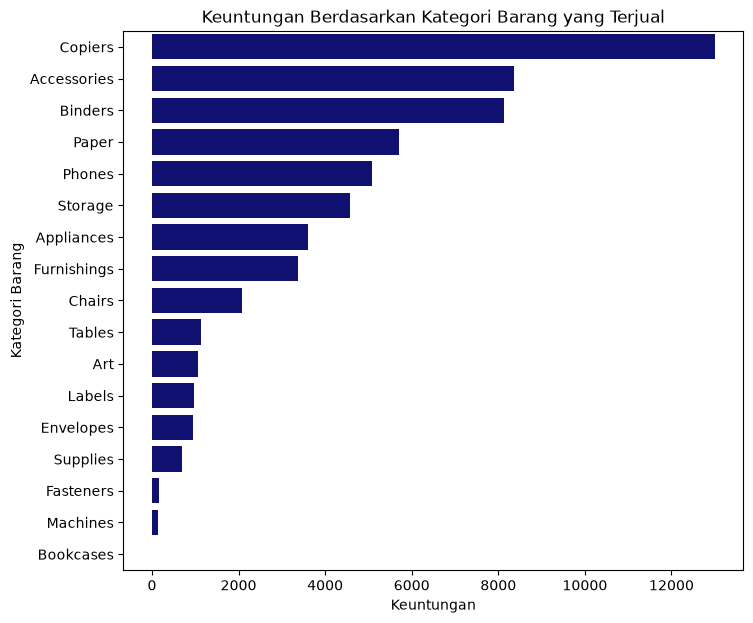

In [55]:
plt.figure(figsize=(8,7))
sns.barplot(
    x=kategori_random["Total_Keuntungan"],
    y=kategori_random["Category"],
    errorbar = ("ci", False),
    color="navy"
)
plt.title("Keuntungan Berdasarkan Kategori Barang yang Terjual")
plt.xlabel("Keuntungan")
plt.ylabel("Kategori Barang")
plt.show()

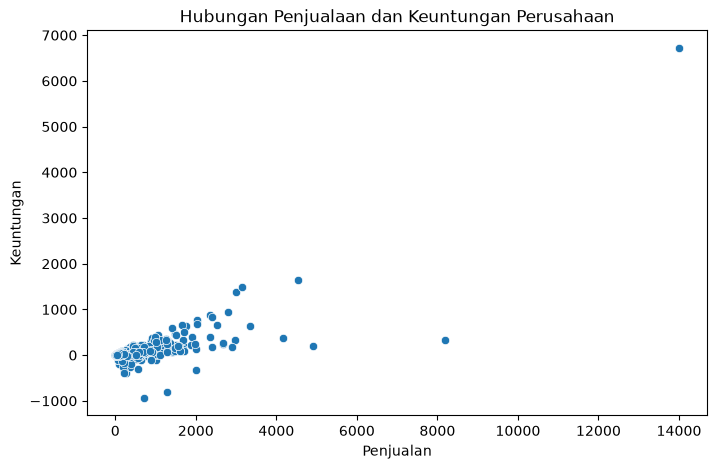

In [56]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=amazon_random["Sales"], y=amazon_random["Profit"])
plt.title("Hubungan Penjualaan dan Keuntungan Perusahaan")
plt.xlabel("Penjualan")
plt.ylabel("Keuntungan")
plt.show()

# Insight

# Recommendation